# BPMN-via-DSL — Evaluation analysis (Phase B)

Presentation-only notebook. **All metric computation lives in the tested
`bpmn_eval` package** and is already written to `results/experiments/results.csv`
and `results.json` by Phase A (`pwsh scripts/run-evaluation.ps1`). This notebook
only *consumes* those outputs to produce the chapter's tables, figures and stats.

Re-run Phase A first if the data is stale.

In [1]:
from itertools import combinations
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

RESULTS_DIR = Path("..") / "results" / "experiments"
FIG_DIR = RESULTS_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(context="notebook", style="whitegrid")
plt.rcParams["figure.dpi"] = 110

# Only models with a complete 15x3 grid are ranked (plan §3.3).
COMPLETE_MODELS = ["OPUS_4_7", "GPT_5_5_THINKING", "GEMINI_3_5_FLASH_THINKING"]
DIFFICULTY_ORDER = ["easy", "medium", "hard", "stress"]
# The discriminating metrics that enter the composite mean (M1 is OUT).
SCORED = [
    "structural_connectedness",
    "element_degree",
    "decision_completeness",
    "label_completeness",
    "gateway_matching",
]

# ---------------------------------------------------------------------------
# Shared presentation style (Spanish, used by every chapter figure).
# One fixed colour per model across ALL figures, coherent with the blue/orange
# palette of the fig1–fig5 (analisis-derivado) series.
# ---------------------------------------------------------------------------
MODEL_COLORS = {
    "OPUS_4_7": "#2c6fbb",                  # blue   (= DSL blue in fig1–fig5)
    "GPT_5_5_THINKING": "#e08a1e",          # orange (= XML orange in fig1–fig5)
    "GEMINI_3_5_FLASH_THINKING": "#7e57c2", # purple (= dsl_v5 in fig1–fig5)
}
MODEL_LABELS = {
    "OPUS_4_7": "Opus 4.7",
    "GPT_5_5_THINKING": "GPT-5.5",
    "GEMINI_3_5_FLASH_THINKING": "Gemini 3.5 Flash",
}
DIFF_LABELS = {"easy": "fácil", "medium": "medio", "hard": "difícil", "stress": "estrés"}
# Two-series palettes (for figures whose bars are metric/element, not model).
ELEMENT_COLORS = {"tasks": "#2c6fbb", "gateways": "#e08a1e"}
RATE_COLORS = {"semantic": "#2c6fbb", "render": "#4fb0a5"}

TITLE_FS, AXIS_FS, TICK_FS, VAL_FS, LEG_FS = 14, 12, 11, 9, 10


def model_name(label):
    return MODEL_LABELS.get(label, label)


def savefig(fig, name, dpi=170):
    for ext in ("png", "pdf"):
        fig.savefig(FIG_DIR / f"{name}.{ext}", bbox_inches="tight", dpi=dpi)
    return fig


def mean_ci(series):
    s = pd.to_numeric(series, errors="coerce").dropna()
    n = len(s)
    m = s.mean()
    if n < 2:
        return pd.Series({"mean": m, "ci95": np.nan, "n": n})
    half = s.std(ddof=1) / np.sqrt(n) * stats.t.ppf(0.975, n - 1)
    return pd.Series({"mean": m, "ci95": half, "n": n})


## 1. Load & sanity checks


In [2]:
df = pd.read_csv(RESULTS_DIR / "results.csv")
with open(RESULTS_DIR / "results.json", encoding="utf-8") as fh:
    report = json.load(fh)
print(f"{len(df)} experiments loaded, {df.shape[1]} columns")
df.head()


420 experiments loaded, 49 columns


,experiment_id,process_id,representation,difficulty,system_prompt_version,process_prompt_version,provider,model_label,run,status,...,messageFlows,dataObjects,tnn,tnsf,cfc_total,cnc_value,has_cycle,n_errors,n_warnings,diagnostic_codes
0,EXP-SYN001-SYSV31-CHATGPT-GPT_5_4_THINKING-R01,SYN001,dsl,easy,SYSV31,PROCv1,ChatGPT,GPT_5_4_THINKING,1,success_with_warnings,...,0.0,0.0,8.0,7.0,0.0,0.875,0.0,0,4,IMPLICIT_END_EVENT;IMPLICIT_START_EVENT;MISSIN...
1,EXP-SYN001-SYSV31-CHATGPT-GPT_5_4_THINKING-R02,SYN001,dsl,easy,SYSV31,PROCv1,ChatGPT,GPT_5_4_THINKING,2,success_with_warnings,...,0.0,0.0,8.0,7.0,0.0,0.875,0.0,0,2,IMPLICIT_END_EVENT;MISSING_EXPLICIT_END_EVENT
2,EXP-SYN001-SYSV31-CHATGPT-GPT_5_4_THINKING-R03,SYN001,dsl,easy,SYSV31,PROCv1,ChatGPT,GPT_5_4_THINKING,3,success_with_warnings,...,0.0,0.0,8.0,7.0,0.0,0.875,0.0,0,4,IMPLICIT_END_EVENT;IMPLICIT_START_EVENT;MISSIN...
3,EXP-SYN001-SYSV31-CHATGPT-GPT_5_5_THINKING-R01,SYN001,dsl,easy,SYSV31,PROCv1,ChatGPT,GPT_5_5_THINKING,1,success,...,0.0,0.0,8.0,7.0,0.0,0.875,0.0,0,0,NaN
4,EXP-SYN001-SYSV31-CHATGPT-GPT_5_5_THINKING-R02,SYN001,dsl,easy,SYSV31,PROCv1,ChatGPT,GPT_5_5_THINKING,2,success,...,0.0,0.0,8.0,7.0,0.0,0.875,0.0,0,0,NaN


In [3]:
print("Status breakdown:")
display(df["status"].value_counts())
print("\nScored source (engine homogeneity — a -Force run should be ~all diagram.bpmn):")
display(df["source"].value_counts())
print("\nPer-model n:")
display(df["model_label"].value_counts())


Status breakdown:


status
success                  199
success_with_warnings    191
semantic_error            24
bpmn_xml_error             6
Name: count, dtype: int64


Scored source (engine homogeneity — a -Force run should be ~all diagram.bpmn):


source
diagram.bpmn    351
output.bpmn      45
none             24
Name: count, dtype: int64


Per-model n:


model_label
GPT_5_5_THINKING             180
GEMINI_3_5_FLASH_THINKING    135
OPUS_4_7                      45
OPUS_4_8_MEDIUM               42
GPT_5_4_THINKING              12
3_1_PRO                        5
OPUS_ADAPTATIVE                1
Name: count, dtype: int64

In [4]:
# Restrict the comparative analysis to the three complete models on the
# HOMOGENEOUS baseline configuration (DSL representation, system prompt v3.1).
# results.csv has since grown to include v4/v5 and zero-shot batches for some
# models; without this filter `cmp` would silently mix configurations and only
# OPUS would stay at n=45. Scoping here keeps every model at the 15x3 grid.
cmp = df[
    (df["representation"] == "dsl")
    & (df["system_prompt_version"] == "SYSV31")
    & df["model_label"].isin(COMPLETE_MODELS)
].copy()
cmp["model_label"] = pd.Categorical(cmp["model_label"], COMPLETE_MODELS, ordered=True)
cmp["difficulty"] = pd.Categorical(cmp["difficulty"], DIFFICULTY_ORDER, ordered=True)
print("Comparison set (DSL · SYSV31 baseline):")
display(cmp.groupby("model_label", observed=True).size().rename("n"))


Comparison set (DSL · SYSV31 baseline):


model_label
OPUS_4_7                     45
GPT_5_5_THINKING             45
GEMINI_3_5_FLASH_THINKING    45
Name: n, dtype: int64

## 2. Robustness (RQ1)

Two separate rates (plan §5.1): **semantic success** (`parserValid ∧ semanticValid`
— measures the model) vs **render success** (`renderValid` — can fail on a
`bpmn-auto-layout` bug, not the model).


,semantic_success,render_success
model_label,,
OPUS_4_7,95.6,95.6
GPT_5_5_THINKING,100.0,100.0
GEMINI_3_5_FLASH_THINKING,95.6,95.6


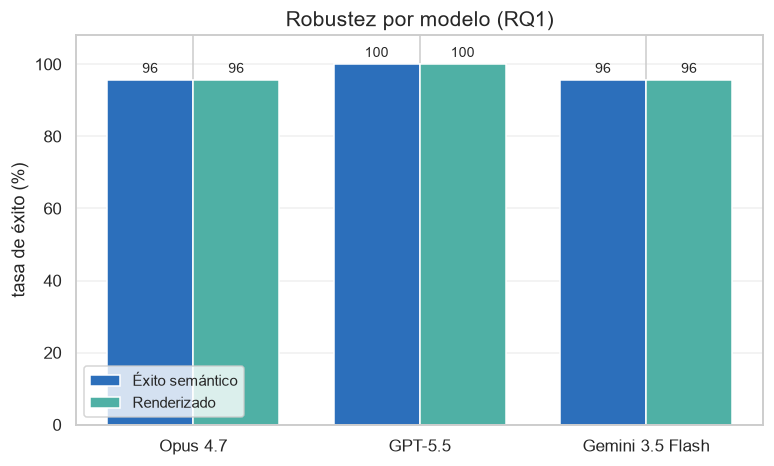

In [5]:
rates = cmp.groupby("model_label", observed=True)[
    ["semantic_success", "render_success"]
].mean().mul(100).round(1)
display(rates)

models = list(rates.index)
x = np.arange(len(models))
w = 0.38
fig, ax = plt.subplots(figsize=(7.2, 4.4))
series = [("semantic_success", "Éxito semántico", RATE_COLORS["semantic"]),
          ("render_success", "Renderizado", RATE_COLORS["render"])]
for i, (col, lbl, color) in enumerate(series):
    offs = x - w / 2 + i * w
    bars = ax.bar(offs, rates[col].values, w, label=lbl, color=color)
    for b, v in zip(bars, rates[col].values):
        ax.text(b.get_x() + b.get_width() / 2, v + 1.2, f"{v:.0f}",
                ha="center", va="bottom", fontsize=VAL_FS)
ax.set_xticks(x)
ax.set_xticklabels([model_name(m) for m in models], fontsize=TICK_FS)
ax.set_ylim(0, 108)
ax.set_ylabel("tasa de éxito (%)", fontsize=AXIS_FS)
ax.set_title("Robustez por modelo (RQ1)", fontsize=TITLE_FS)
ax.legend(fontsize=LEG_FS, loc="lower left")
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
savefig(fig, "rq1_robustness_by_model")
plt.show()


In [6]:
print("Semantic / render success by difficulty:")
display(
    cmp.groupby("difficulty", observed=True)[
        ["semantic_success", "render_success"]
    ].mean().mul(100).round(1)
)


Semantic / render success by difficulty:


,semantic_success,render_success
difficulty,,
easy,100.0,100.0
medium,100.0,100.0
hard,100.0,100.0
stress,55.6,55.6


## 3. Structural quality (RQ2)

Composite `scored_mean` = mean of M2/M3/M4(redefined)/M5/M8 with 95% CIs. M1
(`xml_validity`) is reported separately as a sanity check (it is constant 1.0
over compiled diagrams, hence out of the mean).


In [7]:
ci = cmp.groupby("model_label", observed=True)["scored_mean"].apply(mean_ci).unstack()
display(ci.round(3))
print("Per-metric means (the five discriminating metrics):")
display(cmp.groupby("model_label", observed=True)[SCORED].mean().round(3))
print("M1 xml_validity (sanity only, OUT of the mean):")
display(cmp.groupby("model_label", observed=True)["xml_validity"].mean().round(3))


,mean,ci95,n
model_label,,,
OPUS_4_7,0.833,0.065,45.0
GPT_5_5_THINKING,0.875,0.039,45.0
GEMINI_3_5_FLASH_THINKING,0.804,0.067,45.0


Per-metric means (the five discriminating metrics):


,structural_connectedness,element_degree,decision_completeness,label_completeness,gateway_matching
model_label,,,,,
OPUS_4_7,0.924,0.954,0.902,0.799,0.589
GPT_5_5_THINKING,0.927,1.000,0.856,0.895,0.699
GEMINI_3_5_FLASH_THINKING,0.918,0.954,0.823,0.807,0.515


M1 xml_validity (sanity only, OUT of the mean):


model_label
OPUS_4_7                     0.956
GPT_5_5_THINKING             1.000
GEMINI_3_5_FLASH_THINKING    0.956
Name: xml_validity, dtype: float64

,mean,ci95,n
model_label,,,
OPUS_4_7,0.833,0.065,45.0
GPT_5_5_THINKING,0.875,0.039,45.0
GEMINI_3_5_FLASH_THINKING,0.804,0.067,45.0


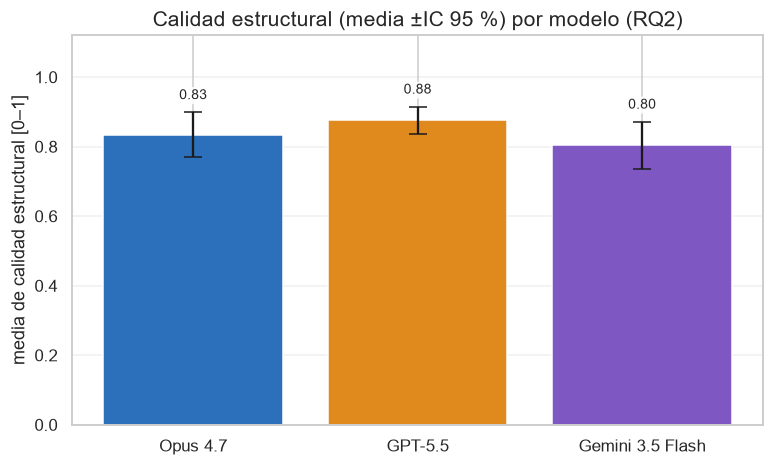

In [8]:
ci = cmp.groupby("model_label", observed=True)["scored_mean"].apply(mean_ci).unstack()
display(ci.round(3))

models = list(ci.index)
colors = [MODEL_COLORS[m] for m in models]
fig, ax = plt.subplots(figsize=(7.2, 4.4))
bars = ax.bar([model_name(m) for m in models], ci["mean"].values,
              yerr=ci["ci95"].values, capsize=6, color=colors)
for b, v, e in zip(bars, ci["mean"].values, ci["ci95"].values):
    top = v + (e if e == e else 0)
    ax.text(b.get_x() + b.get_width() / 2, top + 0.03, f"{v:.2f}",
            ha="center", va="bottom", fontsize=VAL_FS,
            bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.85))
ax.set_ylabel("media de calidad estructural [0–1]", fontsize=AXIS_FS)
ax.set_ylim(0, 1.12)
ax.tick_params(axis="x", labelsize=TICK_FS)
ax.set_title("Calidad estructural (media ±IC 95 %) por modelo (RQ2)", fontsize=TITLE_FS)
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
savefig(fig, "rq2_scored_mean_by_model")
plt.show()


## 4. Descriptive behaviour (RQ2/RQ3)


<home>\AppData\Local\Temp\ipykernel_14312\109799333.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels([model_name(m) for m in COMPLETE_MODELS], fontsize=TICK_FS)
<home>\AppData\Local\Temp\ipykernel_14312\109799333.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels([model_name(m) for m in COMPLETE_MODELS], fontsize=TICK_FS)


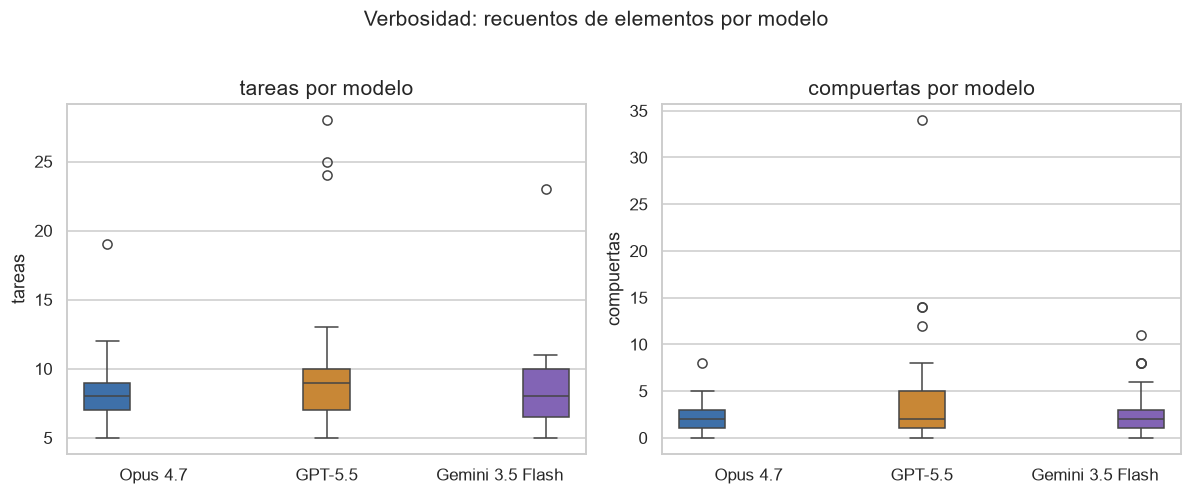

In [9]:
ok = cmp[cmp["semantic_success"] == 1].copy()

# Fig 5.3 — tareas & compuertas distribution per model.
col_es = {"tasks": "tareas", "gateways": "compuertas"}
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
for ax, col in zip(axes, ["tasks", "gateways"]):
    sns.boxplot(
        data=ok, x="model_label", y=col, hue="model_label",
        palette=MODEL_COLORS, legend=False, order=COMPLETE_MODELS, ax=ax,
    )
    ax.set_title(f"{col_es[col]} por modelo", fontsize=TITLE_FS)
    ax.set_xlabel("")
    ax.set_ylabel(col_es[col], fontsize=AXIS_FS)
    ax.set_xticklabels([model_name(m) for m in COMPLETE_MODELS], fontsize=TICK_FS)
fig.suptitle("Verbosidad: recuentos de elementos por modelo", fontsize=TITLE_FS, y=1.02)
fig.tight_layout()
savefig(fig, "rq2_counts_boxplot")
plt.show()


Casos con éxito semántico por (dificultad, modelo):


model_label,OPUS_4_7,GPT_5_5_THINKING,GEMINI_3_5_FLASH_THINKING
difficulty,,,
easy,9,9,9
medium,27,27,27
hard,6,6,6
stress,1,3,1


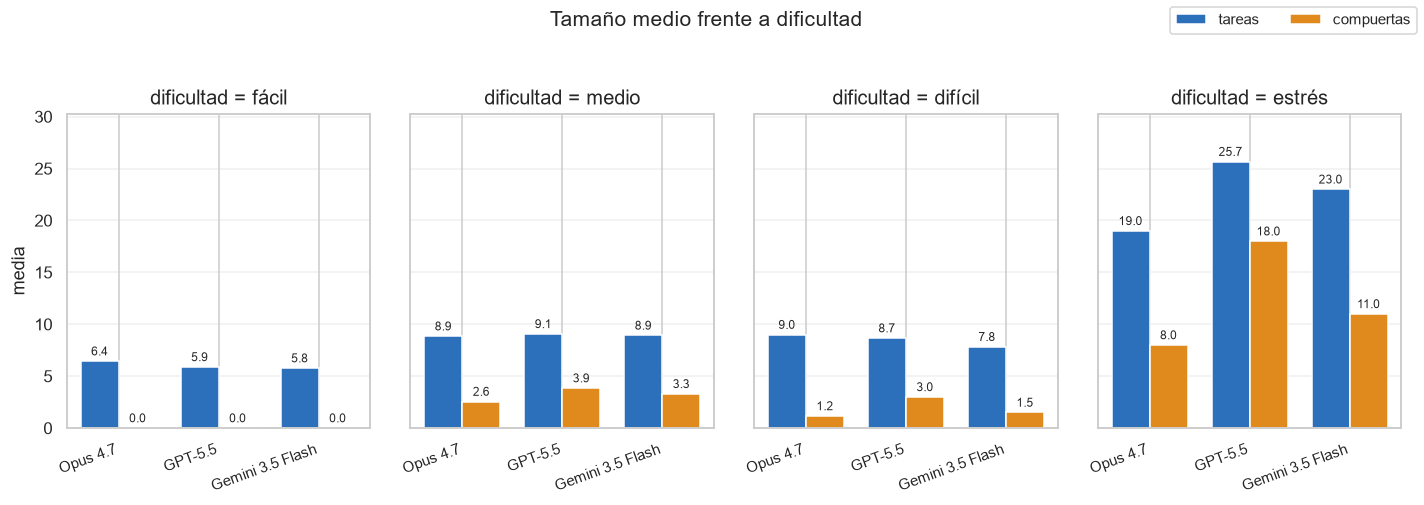

In [10]:
# Fig 5.5 — mean tareas vs compuertas per model, faceted by difficulty.
# Rewritten as explicit matplotlib bars: the old seaborn catplot silently
# dropped a model's bars when a (difficulty, model) cell was thin/empty. Here
# every model keeps its slot and empty cells are annotated "sin datos (n=0)".
elements = [("tasks", "tareas", ELEMENT_COLORS["tasks"]),
            ("gateways", "compuertas", ELEMENT_COLORS["gateways"])]
nmodels = len(COMPLETE_MODELS)
xm = np.arange(nmodels)
bw = 0.38

# Report the per-cell coverage so the Gemini question is auditable.
cov = ok.groupby(["difficulty", "model_label"], observed=True).size().unstack().reindex(DIFFICULTY_ORDER)
print("Casos con éxito semántico por (dificultad, modelo):")
display(cov.fillna(0).astype(int))

means = ok.groupby(["difficulty", "model_label"], observed=True)[["tasks", "gateways"]].mean()
ymax = float(np.nanmax(means.values)) * 1.18 if means.size else 1.0

fig, axes = plt.subplots(1, len(DIFFICULTY_ORDER), figsize=(13, 4.4), sharey=True)
for ax, diff in zip(axes, DIFFICULTY_ORDER):
    for j, (col, lbl, color) in enumerate(elements):
        vals, ns = [], []
        for m in COMPLETE_MODELS:
            sub = ok[(ok["difficulty"] == diff) & (ok["model_label"] == m)]
            ns.append(len(sub))
            vals.append(sub[col].mean() if len(sub) else np.nan)
        offs = xm - bw / 2 + j * bw
        bars = ax.bar(offs, [0 if v != v else v for v in vals], bw,
                      label=lbl if ax is axes[0] else None, color=color)
        for b, v in zip(bars, vals):
            if v == v:
                ax.text(b.get_x() + b.get_width() / 2, v + ymax * 0.01,
                        f"{v:.1f}", ha="center", va="bottom", fontsize=VAL_FS - 1)
    # Annotate models with no semantic-success cases in this facet.
    for k, m in enumerate(COMPLETE_MODELS):
        if len(ok[(ok["difficulty"] == diff) & (ok["model_label"] == m)]) == 0:
            ax.text(xm[k], ymax * 0.04, "sin datos\n(n=0)", ha="center", va="bottom",
                    fontsize=VAL_FS - 1, color="#888888", style="italic")
    ax.set_title(f"dificultad = {DIFF_LABELS[diff]}", fontsize=AXIS_FS + 1)
    ax.set_xticks(xm)
    ax.set_xticklabels([model_name(m) for m in COMPLETE_MODELS], rotation=20,
                       ha="right", fontsize=TICK_FS - 1)
    ax.grid(axis="y", alpha=0.3)
axes[0].set_ylabel("media", fontsize=AXIS_FS)
axes[0].set_ylim(0, ymax)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, fontsize=LEG_FS, loc="upper right", ncol=2)
fig.suptitle("Tamaño medio frente a dificultad", fontsize=TITLE_FS, y=1.04)
fig.tight_layout()
savefig(fig, "rq3_size_vs_difficulty")
plt.show()


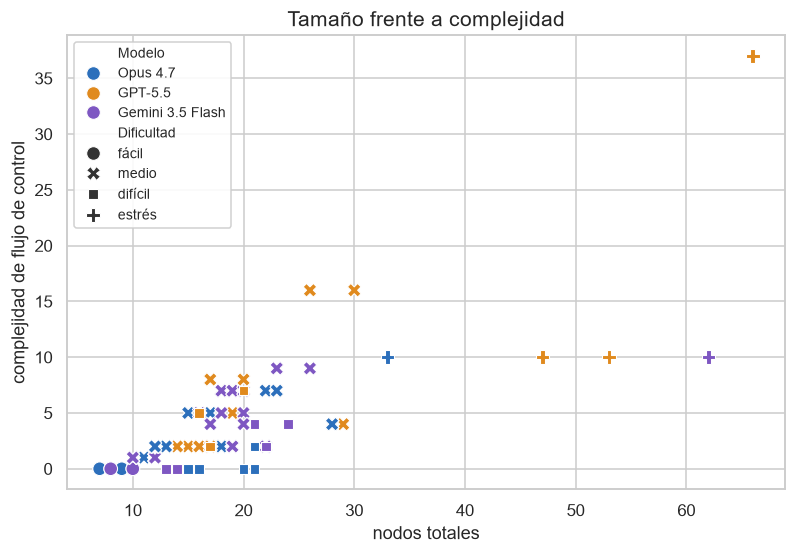

In [11]:
# Fig 5.4 — size vs control-flow complexity.
ok_sc = ok.copy()
ok_sc["Modelo"] = ok_sc["model_label"].map(MODEL_LABELS)
ok_sc["Dificultad"] = ok_sc["difficulty"].astype(str).map(DIFF_LABELS)
hue_order = [MODEL_LABELS[m] for m in COMPLETE_MODELS]
style_order = [DIFF_LABELS[d] for d in DIFFICULTY_ORDER]
palette = {MODEL_LABELS[m]: MODEL_COLORS[m] for m in COMPLETE_MODELS}

fig, ax = plt.subplots(figsize=(7.4, 5.2))
sns.scatterplot(
    data=ok_sc, x="tnn", y="cfc_total", hue="Modelo", style="Dificultad",
    hue_order=hue_order, style_order=style_order, palette=palette, s=80, ax=ax,
)
ax.set_xlabel("nodos totales", fontsize=AXIS_FS)
ax.set_ylabel("complejidad de flujo de control", fontsize=AXIS_FS)
ax.set_title("Tamaño frente a complejidad", fontsize=TITLE_FS)
ax.tick_params(labelsize=TICK_FS)
ax.legend(fontsize=LEG_FS - 1, loc="upper left", framealpha=0.9)
fig.tight_layout()
savefig(fig, "rq2_size_complexity_scatter")
plt.show()


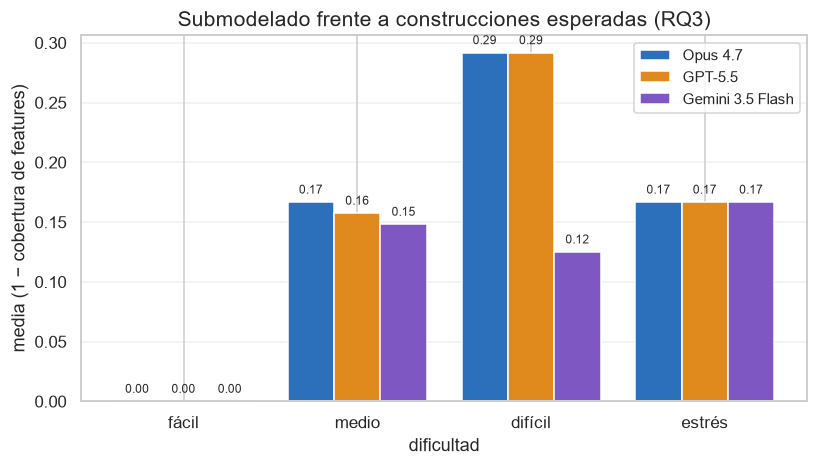

In [12]:
# Fig 5.6 — under-modeling: 1 - feature coverage (a genuine quality signal).
fc_ok = ok.dropna(subset=["feature_coverage"]).copy()
fc_ok["under_modeling"] = 1 - fc_ok["feature_coverage"]
piv = fc_ok.pivot_table(
    index="difficulty", columns="model_label", values="under_modeling",
    observed=True, aggfunc="mean",
).reindex(DIFFICULTY_ORDER)

diffs = list(piv.index)
x = np.arange(len(diffs))
present = [m for m in COMPLETE_MODELS if m in piv.columns]
w = 0.8 / len(present)
fig, ax = plt.subplots(figsize=(7.6, 4.4))
for i, m in enumerate(present):
    vals = piv[m].values
    offs = x - 0.4 + w / 2 + i * w
    bars = ax.bar(offs, np.nan_to_num(vals), w, label=model_name(m), color=MODEL_COLORS[m])
    for b, v in zip(bars, vals):
        if v == v:
            ax.text(b.get_x() + b.get_width() / 2, v + 0.005, f"{v:.2f}",
                    ha="center", va="bottom", fontsize=VAL_FS - 1)
ax.set_xticks(x)
ax.set_xticklabels([DIFF_LABELS[d] for d in diffs], fontsize=TICK_FS)
ax.set_xlabel("dificultad", fontsize=AXIS_FS)
ax.set_ylabel("media (1 − cobertura de features)", fontsize=AXIS_FS)
ax.set_title("Submodelado frente a construcciones esperadas (RQ3)", fontsize=TITLE_FS)
ax.legend(fontsize=LEG_FS)
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
savefig(fig, "rq3_under_modeling")
plt.show()


## 5. Semantic coverage — Level 0 (RQ4)


In [13]:
fc = cmp.dropna(subset=["feature_coverage"])
display(
    fc.groupby("model_label", observed=True)["feature_coverage"]
    .apply(mean_ci).unstack().round(3)
)
print("Most frequently MISSED expected features:")
miss = (
    fc.assign(missing=fc["missing_features"].fillna("").str.split(";"))
    .explode("missing")
)
miss = miss[miss["missing"] != ""]
display(miss["missing"].value_counts().head(15))


,mean,ci95,n
model_label,,,
OPUS_4_7,0.813,0.091,45.0
GPT_5_5_THINKING,0.856,0.083,45.0
GEMINI_3_5_FLASH_THINKING,0.846,0.091,45.0


Most frequently MISSED expected features:


missing
message_flow                27
multiple_pools              18
send_receive                18
cancellation                 5
exception_flow               5
annotations                  4
multiple_lanes               4
xor_gateway                  4
parallel_gateway             4
data_objects                 4
timer_or_exception_event     4
Name: count, dtype: int64

## 6. Behavioural validity — Level 1a diagnostics taxonomy (RQ4)


In [14]:
diag = report.get("diagnostics", {})
by_model = pd.DataFrame(diag.get("model_label", {})).fillna(0).astype(int)
# keep only complete models, drop all-zero codes
cols = [m for m in COMPLETE_MODELS if m in by_model.columns]
by_model = by_model[cols]
by_model = by_model.loc[by_model.sum(axis=1) > 0]
display(by_model.sort_values(cols[0] if cols else by_model.columns[0], ascending=False))


,OPUS_4_7,GPT_5_5_THINKING,GEMINI_3_5_FLASH_THINKING
IMPLICIT_END_EVENT,104,51,107
MISSING_EXPLICIT_END_EVENT,34,20,36
IMPLICIT_START_EVENT,33,29,43
MISSING_EXPLICIT_START_EVENT,23,25,15
IMPLICIT_BOUNDARY_END_EVENT,4,8,11
AP-7,3,0,20
DUPLICATED_DATA_OBJECT,3,17,11
ACTIVITY_WITHOUT_INCOMING,1,0,1
SEQUENCE_FLOW_INVALID_REFERENCE,1,0,1
BRANCH_WITHOUT_END_REACHABILITY,0,9,0


In [15]:
print("Diagnostic codes by difficulty:")
by_diff = pd.DataFrame(diag.get("difficulty", {})).fillna(0).astype(int)
display(by_diff)


Diagnostic codes by difficulty:


,easy,hard,medium,stress
IMPLICIT_END_EVENT,32,60,198,59
MISSING_EXPLICIT_END_EVENT,31,18,72,1
IMPLICIT_START_EVENT,28,28,66,39
MISSING_EXPLICIT_START_EVENT,27,12,49,9
IMPLICIT_BOUNDARY_END_EVENT,0,23,0,1
AP-7,0,3,3,51
ACTIVITY_WITHOUT_INCOMING,0,2,0,0
SEQUENCE_FLOW_INVALID_REFERENCE,0,2,0,0
DUPLICATED_DATA_OBJECT,0,0,26,5
BRANCH_WITHOUT_END_REACHABILITY,0,0,7,2


## 7. Statistics (RQ2/RQ7)

Non-parametric Kruskal–Wallis across the three complete models on `scored_mean`,
then pairwise Mann–Whitney U. Run-to-run variance (R01–R03) reported as a
stability/determinism result.


In [16]:
groups = [g["scored_mean"].dropna().values for _, g in cmp.groupby("model_label", observed=True)]
H, p = stats.kruskal(*groups)
print(f"Kruskal-Wallis on scored_mean: H={H:.3f}, p={p:.4g}")
print("\nPairwise Mann-Whitney U (scored_mean):")
for a, b in combinations(COMPLETE_MODELS, 2):
    sa = cmp[cmp["model_label"] == a]["scored_mean"].dropna()
    sb = cmp[cmp["model_label"] == b]["scored_mean"].dropna()
    u, pu = stats.mannwhitneyu(sa, sb, alternative="two-sided")
    print(f"  {a} vs {b}: U={u:.0f}, p={pu:.4g}")


Kruskal-Wallis on scored_mean: H=3.414, p=0.1814

Pairwise Mann-Whitney U (scored_mean):
  OPUS_4_7 vs GPT_5_5_THINKING: U=848, p=0.1835
  OPUS_4_7 vs GEMINI_3_5_FLASH_THINKING: U=1049, p=0.771
  GPT_5_5_THINKING vs GEMINI_3_5_FLASH_THINKING: U=1236, p=0.07202


In [17]:
# Run-to-run stability: within (model, process) std across R01-R03, averaged.
var = (
    cmp.groupby(["model_label", "process_id"], observed=True)["scored_mean"]
    .std()
    .groupby("model_label", observed=True)
    .mean()
    .rename("mean within-cell std (lower = more stable)")
)
display(var.round(4))


model_label
OPUS_4_7                     0.0769
GPT_5_5_THINKING             0.0550
GEMINI_3_5_FLASH_THINKING    0.0639
Name: mean within-cell std (lower = more stable), dtype: float64

## 8. System-prompt sensitivity — v3.1 vs v4 (RQ5)

Partial ablation on the SAME processes SYN013–015 × the 3 complete models. Until
the v4 data is generated (plan Step 6) only one prompt version is present.


In [18]:
abl = df[
    df["process_id"].isin(["SYN013", "SYN014", "SYN015"])
    & df["model_label"].isin(COMPLETE_MODELS)
]
versions = abl["system_prompt_version"].nunique()
if versions > 1:
    display(
        abl.groupby(["system_prompt_version", "model_label"], observed=True)["scored_mean"]
        .mean().unstack().round(3)
    )
else:
    print(
        "Only one system_prompt_version present "
        f"({sorted(abl['system_prompt_version'].unique())}). "
        "Generate v4 runs (Step 6) to populate this ablation."
    )


model_label,GEMINI_3_5_FLASH_THINKING,GPT_5_5_THINKING,OPUS_4_7
system_prompt_version,,,
SYSV31,0.546,0.823,0.671
SYSV4,0.562,0.728,NaN
SYSV5,0.648,0.652,NaN
ZSXML,NaN,0.835,NaN


## 9. Input-length sensitivity — PROCv1 vs PROCv2 (RQ6)


In [19]:
versions = df["process_prompt_version"].nunique()
if versions > 1:
    sub = df[df["model_label"].isin(COMPLETE_MODELS)]
    display(
        sub.groupby(["process_prompt_version", "model_label"], observed=True)["scored_mean"]
        .mean().unstack().round(3)
    )
else:
    print(
        "Only one process_prompt_version present "
        f"({sorted(df['process_prompt_version'].dropna().unique())}). "
        "Author long PROCv2 variants (Step 7) to populate this section."
    )


Only one process_prompt_version present (['PROCv1']). Author long PROCv2 variants (Step 7) to populate this section.


## 10. External-validity appendix (real / Spanish processes)


In [20]:
real = df[~df["process_id"].str.startswith("SYN", na=False)]
if len(real):
    display(
        real.groupby("process_id")[
            ["semantic_success", "render_success", "scored_mean", "feature_coverage"]
        ].mean().round(3)
    )
else:
    print("No non-synthetic processes yet (plan Step 8 — external validity set).")


No non-synthetic processes yet (plan Step 8 — external validity set).


## 11. Figure export

Every figure above is written to `results/experiments/figures/` as both PNG and
PDF via `savefig(...)`. List them:


In [21]:
for f in sorted(FIG_DIR.glob("*.png")):
    print(f.name)


rq1_robustness_by_model.png
rq2_counts_boxplot.png
rq2_scored_mean_by_model.png
rq2_size_complexity_scatter.png
rq3_size_vs_difficulty.png
rq3_under_modeling.png
